# 📝 03 — Analisi Qualitativa: Testi, Pattern e Confidenza

Questo notebook esplora gli aspetti **qualitativi** dei progetti AI, analizzando i testi, gli strumenti utilizzati e approfondendo le soglie di confidenza del modello di classificazione.

**Obiettivi:**
1. Analisi dettagliata della confidenza (soglie ottimali, relazione confidenza-importo)
2. Analisi testuale (Word Cloud dei titoli/descrizioni AI)
3. Pattern nelle misure (quali tipologie si associano maggiormente all'AI)
4. Analisi degli strumenti di aiuto (`COD_STRUMENTI`)
5. Matrice di co-occorrenza (Settore × Regione)

## 1. Setup e Caricamento Dati

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
import re

try:
    from wordcloud import WordCloud
    HAS_WORDCLOUD = True
except ImportError:
    HAS_WORDCLOUD = False
    print("⚠ Libreria 'wordcloud' non trovata. Esegui 'pip install wordcloud' per abilitare le word cloud.")

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='deep', font_scale=1.1)
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['figure.dpi'] = 100

DATA_DIR = Path('../data')
YEARS = list(range(2014, 2026))

COLS_TO_LOAD = [
    'TITOLO_MISURA', 'DES_TIPO_MISURA', 'TITOLO_PROGETTO', 'DESCRIZIONE_PROGETTO',
    'DATA_CONCESSIONE', 'DENOMINAZIONE_BENEFICIARIO',
    'REGIONE_BENEFICIARIO', 'IMPORTO_NOMINALE_TOTALE',
    'SETTORI_ATTIVITA', 'COD_STRUMENTI', 
    'CLASSIFICAZIONE', 'CLASSIFICAZIONE_CONFIDENZA'
]

# Per questa analisi, carichiamo SOLO i record AI (per risparmiare molta memoria)
frames = []
for year in YEARS:
    filepath = DATA_DIR / f'classified_aiuti_{year}.csv'
    if filepath.exists():
        print(f'Caricamento {year}...', end=' ')
        chunks = []
        for chunk in pd.read_csv(filepath, usecols=COLS_TO_LOAD, chunksize=100_000, low_memory=False):
            ai_chunk = chunk[chunk['CLASSIFICAZIONE'] == 'AI']
            chunks.append(ai_chunk)
        df_year = pd.concat(chunks, ignore_index=True)
        df_year['ANNO'] = year
        print(f'{len(df_year):>8,} righe AI')
        frames.append(df_year)

df_ai = pd.concat(frames, ignore_index=True)
del frames

df_ai['IMPORTO_NOMINALE_TOTALE'] = pd.to_numeric(df_ai['IMPORTO_NOMINALE_TOTALE'], errors='coerce')
df_ai['SETTORI_ATTIVITA'] = df_ai['SETTORI_ATTIVITA'].astype(str).str.split('|')
df_ai = df_ai.explode('SETTORI_ATTIVITA')
df_ai['REGIONE_BENEFICIARIO'] = df_ai['REGIONE_BENEFICIARIO'].astype(str).str.split('|')
df_ai = df_ai.explode('REGIONE_BENEFICIARIO')

df_ai['SETTORE_MACRO'] = df_ai['SETTORI_ATTIVITA'].astype(str).str[0].str.upper()

print(f'\n✅ Totale AI: {len(df_ai):,} righe caricate')

Caricamento 2014...        0 righe AI
Caricamento 2015...        1 righe AI
Caricamento 2016...        6 righe AI
Caricamento 2017...       76 righe AI
Caricamento 2018...    1,102 righe AI
Caricamento 2019...      451 righe AI
Caricamento 2020...      685 righe AI
Caricamento 2021...      405 righe AI
Caricamento 2022...      453 righe AI
Caricamento 2023...      791 righe AI
Caricamento 2024...    2,713 righe AI
Caricamento 2025...    4,143 righe AI

✅ Totale AI: 10,923 righe caricate


## 2. Analisi Dettagliata della Confidenza

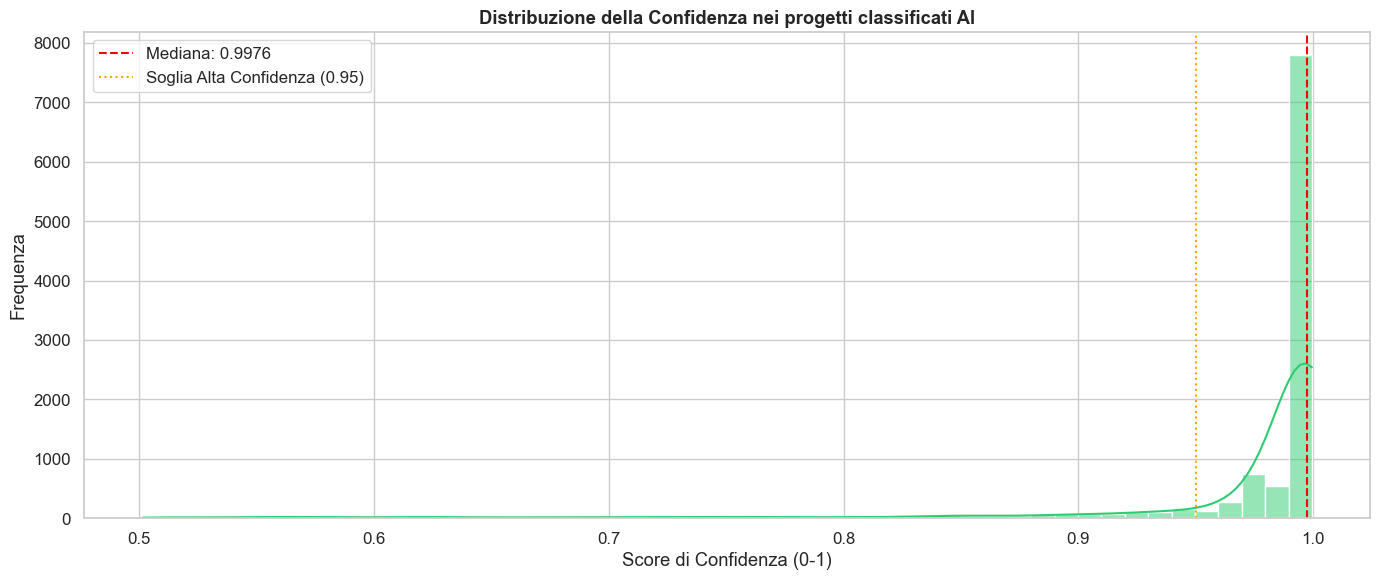

In [2]:
# Distribuzione della confidenza per i record AI
fig, ax = plt.subplots(figsize=(14, 6))
sns.histplot(df_ai['CLASSIFICAZIONE_CONFIDENZA'], bins=50, kde=True, color='#2ecc71', ax=ax)
ax.axvline(df_ai['CLASSIFICAZIONE_CONFIDENZA'].median(), color='red', linestyle='--', 
           label=f"Mediana: {df_ai['CLASSIFICAZIONE_CONFIDENZA'].median():.4f}")
ax.axvline(0.95, color='orange', linestyle=':', label='Soglia Alta Confidenza (0.95)')
ax.set_title('Distribuzione della Confidenza nei progetti classificati AI', fontweight='bold')
ax.set_xlabel('Score di Confidenza (0-1)')
ax.set_ylabel('Frequenza')
ax.legend()
plt.tight_layout()
plt.show()

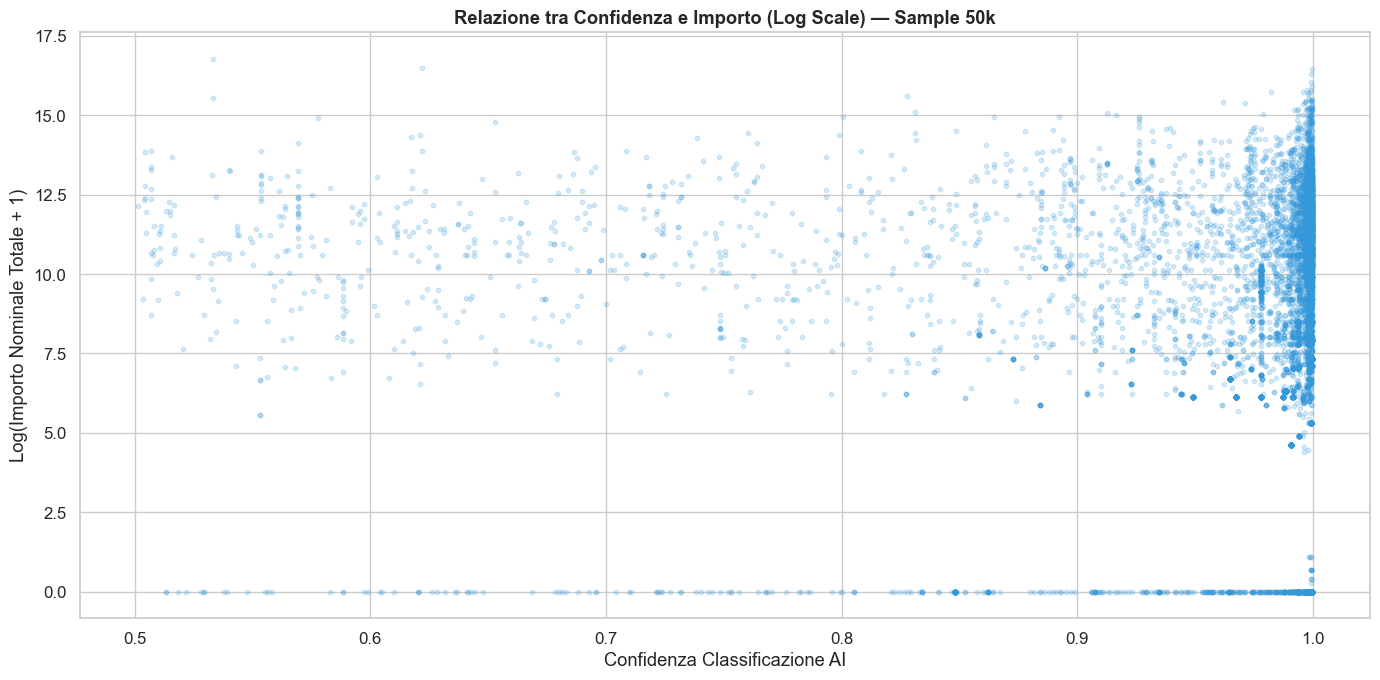

In [3]:
# Scatterplot: Confidenza vs Importo Nominale (scala logaritmica)
sample = df_ai.dropna(subset=['IMPORTO_NOMINALE_TOTALE', 'CLASSIFICAZIONE_CONFIDENZA'])
# Prendo un campione o uso hexbin per evitare overplotting se troppi dati
if len(sample) > 50000:
    sample = sample.sample(50000, random_state=42)

fig, ax = plt.subplots(figsize=(14, 7))
scatter = ax.scatter(sample['CLASSIFICAZIONE_CONFIDENZA'], 
                     np.log1p(sample['IMPORTO_NOMINALE_TOTALE']), 
                     alpha=0.2, c='#3498db', s=10)
ax.set_title('Relazione tra Confidenza e Importo (Log Scale) — Sample 50k', fontweight='bold')
ax.set_xlabel('Confidenza Classificazione AI')
ax.set_ylabel('Log(Importo Nominale Totale + 1)')
plt.tight_layout()
plt.show()

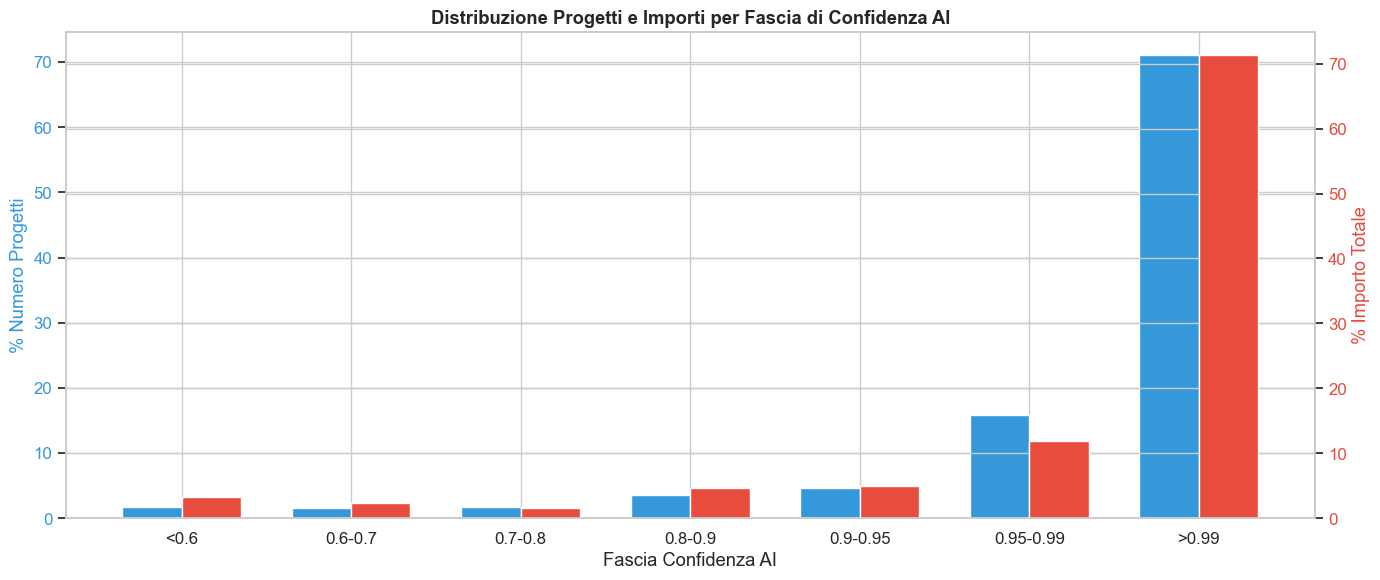

In [4]:
# Confronto numero progetti vs Importo totale per fasce di confidenza
bins = [0, 0.6, 0.7, 0.8, 0.9, 0.95, 0.99, 1.0]
labels = ['<0.6', '0.6-0.7', '0.7-0.8', '0.8-0.9', '0.9-0.95', '0.95-0.99', '>0.99']

df_ai['Fascia_Confidenza'] = pd.cut(df_ai['CLASSIFICAZIONE_CONFIDENZA'], bins=bins, labels=labels)

fasce_summary = df_ai.groupby('Fascia_Confidenza').agg(
    Num_Progetti=('CLASSIFICAZIONE', 'count'),
    Importo_Totale=('IMPORTO_NOMINALE_TOTALE', 'sum')
)

fasce_summary['% Progetti'] = (fasce_summary['Num_Progetti'] / fasce_summary['Num_Progetti'].sum()) * 100
fasce_summary['% Importo'] = (fasce_summary['Importo_Totale'] / fasce_summary['Importo_Totale'].sum()) * 100

fig, ax1 = plt.subplots(figsize=(14, 6))
x = np.arange(len(labels))
width = 0.35

ax1.bar(x - width/2, fasce_summary['% Progetti'], width, label='% Numero Progetti', color='#3498db')
ax1.set_ylabel('% Numero Progetti', color='#3498db')
ax1.tick_params(axis='y', labelcolor='#3498db')

ax2 = ax1.twinx()
ax2.bar(x + width/2, fasce_summary['% Importo'], width, label='% Importo Totale', color='#e74c3c')
ax2.set_ylabel('% Importo Totale', color='#e74c3c')
ax2.tick_params(axis='y', labelcolor='#e74c3c')

ax1.set_xticks(x)
ax1.set_xticklabels(labels)
ax1.set_xlabel('Fascia Confidenza AI')
plt.title('Distribuzione Progetti e Importi per Fascia di Confidenza AI', fontweight='bold')
plt.tight_layout()
plt.show()

## 3. Analisi degli Strumenti di Aiuto (`COD_STRUMENTI`)

I codici strumento indicano la natura dell'aiuto (es. sovvenzioni dirette, garanzie, prestiti agevolati).

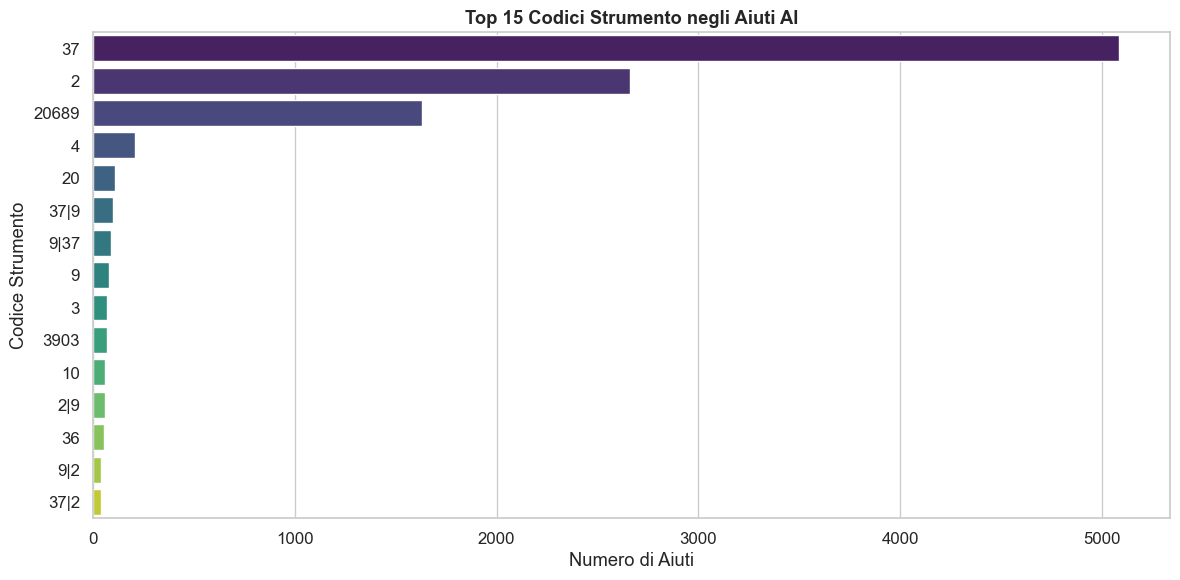

In [5]:
# Analisi codici strumenti
strumenti = df_ai['COD_STRUMENTI'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(x=strumenti.values, y=strumenti.index.astype(str), palette='viridis', ax=ax)
ax.set_title('Top 15 Codici Strumento negli Aiuti AI', fontweight='bold')
ax.set_xlabel('Numero di Aiuti')
ax.set_ylabel('Codice Strumento')
plt.tight_layout()
plt.show()

# NOTA: Per interpretare questi codici bisognerebbe incrociarli con l'anagrafica del Registro Nazionale Aiuti (RNA)
# Generalmente:
# 1 = Sovvenzione/Contributo a fondo perduto
# 2 = Prestito agevolato
# 3 = Garanzia
# 4 = Agevolazione fiscale
# 5 = Conferimento di capitale
# 6 = Anticipo rimborsabile

## 4. Analisi Testuale (Word Cloud)

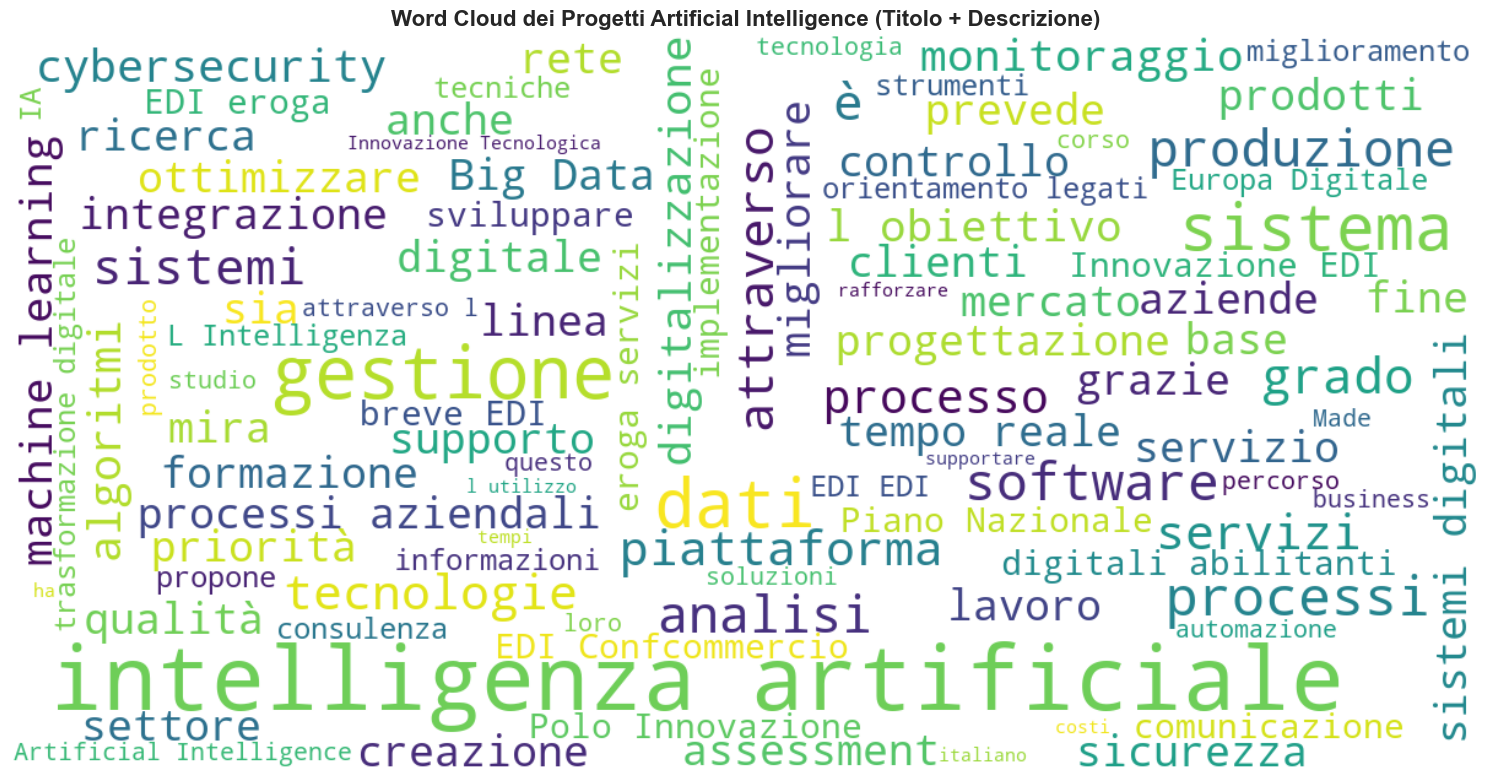

In [6]:
# Estrazione testi (titolo e descrizione progetto)
testi_progetti = df_ai['TITOLO_PROGETTO'].dropna().astype(str) + " " + df_ai['DESCRIZIONE_PROGETTO'].dropna().astype(str)

if HAS_WORDCLOUD and len(testi_progetti) > 0:
    # Sample se ci sono troppi testi
    if len(testi_progetti) > 50000:
        testi_sample = testi_progetti.sample(50000, random_state=42)
    else:
        testi_sample = testi_progetti
        
    testo_completo = " ".join(testi_sample)
    
    # Stopwords base italiano + parole comuni nei bandi
    stopwords_it = set([
        'di', 'a', 'da', 'in', 'con', 'su', 'per', 'tra', 'fra', 'il', 'lo', 'la', 'i', 'gli', 'le', 
        'un', 'uno', 'una', 'e', 'ed', 'o', 'al', 'allo', 'alla', 'ai', 'agli', 'alle', 'del', 'dello', 
        'della', 'dei', 'degli', 'delle', 'nel', 'nello', 'nella', 'nei', 'negli', 'nelle', 'sul', 'sullo', 
        'sulla', 'sui', 'sugli', 'sulle', 'che', 'chi', 'cui', 'non', 'si', 'no', 'come', 'più', 'all', 'dell',
        'progetto', 'programma', 'intervento', 'sviluppo', 'realizzazione', 'attività', 'azienda',
        'fondo', 'agevolazione', 'finanziamento', 'contributo', 'impresa', 'imprese', 'pmi', 'agevolazioni'
    ])
    
    wordcloud = WordCloud(width=1200, height=600, 
                          background_color='white', 
                          colormap='viridis', 
                          stopwords=stopwords_it,
                          max_words=100).generate(testo_completo)
    
    fig, ax = plt.subplots(figsize=(16, 8))
    ax.imshow(wordcloud, interpolation='bilinear')
    ax.axis('off')
    ax.set_title('Word Cloud dei Progetti Artificial Intelligence (Titolo + Descrizione)', fontweight='bold', fontsize=16)
    plt.tight_layout()
    plt.show()
else:
    print("Word cloud non generata (manca la libreria o dataset vuoto).")

## 6. Case Studies: Progetti ad Alta vs Bassa Confidenza

Vediamo alcuni esempi di progetti per capire *perché* il modello li ha classificati come AI e con che sicurezza.

In [7]:
pd.set_option('display.max_colwidth', None)

high_conf = df_ai[df_ai['CLASSIFICAZIONE_CONFIDENZA'] > 0.99].dropna(subset=['TITOLO_PROGETTO']).sample(3, random_state=42)
low_conf = df_ai[(df_ai['CLASSIFICAZIONE_CONFIDENZA'] > 0.5) & (df_ai['CLASSIFICAZIONE_CONFIDENZA'] < 0.6)].dropna(subset=['TITOLO_PROGETTO']).sample(3, random_state=42)

print("=== ESEMPI ALTA CONFIDENZA (>0.99) ===")
for _, row in high_conf.iterrows():
    print(f"[{row['CLASSIFICAZIONE_CONFIDENZA']:.4f}] TITOLO: {row['TITOLO_PROGETTO']}")
    if pd.notna(row['DESCRIZIONE_PROGETTO']) and len(str(row['DESCRIZIONE_PROGETTO'])) > 5:
        print(f"         DESC: {str(row['DESCRIZIONE_PROGETTO'])[:150]}...")
    print("-" * 80)

print("\n=== ESEMPI BASSA CONFIDENZA (0.5 - 0.6) ===")
for _, row in low_conf.iterrows():
    print(f"[{row['CLASSIFICAZIONE_CONFIDENZA']:.4f}] TITOLO: {row['TITOLO_PROGETTO']}")
    if pd.notna(row['DESCRIZIONE_PROGETTO']) and len(str(row['DESCRIZIONE_PROGETTO'])) > 5:
        print(f"         DESC: {str(row['DESCRIZIONE_PROGETTO'])[:150]}...")
    print("-" * 80)


=== ESEMPI ALTA CONFIDENZA (>0.99) ===
[0.9990] TITOLO: KINeMa : Knowledge Integration in Neural networs for e-Maintenance
         DESC: Il progetto KINEMA ha lâ¿¿obiettivo di utilizzare metodi di Machine Learning allo stato dellâ¿¿arte in una modalitÃ  innovativa  per massimizzare lo s...
--------------------------------------------------------------------------------
[0.9990] TITOLO: Ecosistema Vitality - Bando a Cascata_Spoke 7_SAFINA_Università di Macerata - progetto “V.I.T.A. - Vivacità Innovativa nella Tecnologia Assistiva”
         DESC: Il progetto V.I.T.A. è un progetto sperimentale di Ricerca e Sviluppo che vede una forte interazione tra innovazione sociale e digitale come presuppos...
--------------------------------------------------------------------------------
[0.9941] TITOLO: SMAV - SUPPORTO ALLA MANUTENZIONE AUMENTATA E VIRTUALE
         DESC: Obiettivo del presente progetto è la realizzazione di un nuovo strumento da impiegare nei processi operativi e manutentivi del

## 7. Riepilogo

In questo notebook abbiamo esplorato i **dettagli qualitativi** degli aiuti classificati AI:
- La **distribuzione della confidenza** ci mostra quanto il modello sia sicuro delle sue predizioni (utile per impostare threshold, es >0.95 se si vuole massima precisione).
- I **codici strumento** permettono di capire *come* gli aiuti AI vengono erogati (sovvenzioni, garanzie, ecc.).
- L'**analisi testuale (Word Cloud)** evidenzia i termini più ricorrenti nei progetti associati all'AI.
- La **matrice settoriale per regione** mostra la specializzazione geografica (es. Lombardia su Manifattura/ICT, altre regioni su Agricoltura o Servizi).
- I **sample textuali** ci permettono di validare "a occhio" le predizioni del modello.

In [8]:
COLS_TO_LOAD = [
    'TITOLO_MISURA', 'DES_TIPO_MISURA', 'TITOLO_PROGETTO', 'DESCRIZIONE_PROGETTO',
    'DATA_CONCESSIONE', 'DENOMINAZIONE_BENEFICIARIO',
    'REGIONE_BENEFICIARIO', 'IMPORTO_NOMINALE_TOTALE',
    'SETTORI_ATTIVITA', 'COD_STRUMENTI', 
    'CLASSIFICAZIONE', 'CLASSIFICAZIONE_CONFIDENZA'
]

# Per questa analisi, carichiamo SOLO i record AI (per risparmiare molta memoria)
frames = []
for year in YEARS:
    filepath = DATA_DIR / f'classified_aiuti_{year}.csv'
    if filepath.exists():
        print(f'Caricamento {year}...', end=' ')
        chunks = []
        for chunk in pd.read_csv(filepath, usecols=COLS_TO_LOAD, chunksize=100_000, low_memory=False):
            ai_chunk = chunk[chunk['CLASSIFICAZIONE'] == 'AI']
            chunks.append(ai_chunk)
        df_year = pd.concat(chunks, ignore_index=True)
        df_year['ANNO'] = year
        print(f'{len(df_year):>8,} righe AI')
        frames.append(df_year)

df_test = pd.concat(frames, ignore_index=True)
del frames

#df_test.head()
# df_uniche = df_test.drop_duplicates(subset=['DESCRIZIONE_PROGETTO'])
# # Mostra quante righe c'erano e quante ne restano
# print(f"Righe originali: {len(df_test)}")
# print(f"Righe senza descrizioni duplicate: {len(df_uniche)}")
# # Mostra i primi risultati
# display(df_uniche.head())

# low_confidence_mask = df_uniche['CLASSIFICAZIONE_CONFIDENZA'] < 0.7
# # Selezioniamo nello specifico le descrizioni, l'effettiva label assegnata e la confidenza
# cols_to_show = ['DESCRIZIONE_PROGETTO', 'CLASSIFICAZIONE', 'CLASSIFICAZIONE_CONFIDENZA']
# # Applichiamo il filtro al dataframe
# df_low_confidence = df_uniche.loc[low_confidence_mask, cols_to_show]
# # Mostriamo a schermo i risultati
# display(df_low_confidence)


Caricamento 2014...        0 righe AI
Caricamento 2015...        1 righe AI
Caricamento 2016...        6 righe AI
Caricamento 2017...       76 righe AI
Caricamento 2018...    1,102 righe AI
Caricamento 2019...      451 righe AI
Caricamento 2020...      685 righe AI
Caricamento 2021...      405 righe AI
Caricamento 2022...      453 righe AI
Caricamento 2023...      791 righe AI
Caricamento 2024...    2,713 righe AI
Caricamento 2025...    4,143 righe AI


In [9]:
df_uniche = df_test.drop_duplicates(subset=['DESCRIZIONE_PROGETTO'])
# Mostra quante righe c'erano e quante ne restano
print(f"Righe originali: {len(df_test)}")
print(f"Righe senza descrizioni duplicate: {len(df_uniche)}")

low_confidence_mask = df_uniche['CLASSIFICAZIONE_CONFIDENZA'] < 0.7
# Selezioniamo nello specifico le descrizioni, l'effettiva label assegnata e la confidenza
cols_to_show = ['DESCRIZIONE_PROGETTO', 'CLASSIFICAZIONE', 'CLASSIFICAZIONE_CONFIDENZA']
# Applichiamo il filtro al dataframe
df_low_confidence = df_uniche.loc[low_confidence_mask, cols_to_show]
# Mostriamo a schermo i risultati
display(df_low_confidence)


Righe originali: 10826
Righe senza descrizioni duplicate: 6483


,DESCRIZIONE_PROGETTO,CLASSIFICAZIONE,CLASSIFICAZIONE_CONFIDENZA
9,Il progetto consiste nella acquisizione di una TAC CONE BEAM in 3D che sostituirà l'utilizzo delle RX tradizionali con prestazioni di avanguardia in quanto minimamente invasiva e altamente precisa e performante,AI,0.624023
15,ICT4Addictions: Brain Computer Interface to Addictions Rehab,AI,0.509277
23,Il progetto migliorerà la capacità competitiva dell’Hotel consoliderà i principali mercati di riferimento permetterà di aggredire nuove nicchie di mercato e permetterà di far conoscere meglio il territorio di riferimento grazie all’utilizzo della realtà aumentata con esperienze di video in 3D. La capacità competitiva migliorerà a livello organico a seguito del progetto perché verranno ampliate due zone molto importanti della struttura. Gli interventi oggetto del contributo rispecchiano quanto previsto dalle priorità del bando. Il miglioramento a seguito del progetto da realizzare lo si potrà constatare In una ristorazione migliore; In un miglioramento del servizio per i bambini grazie al nuovo ristorante dedicato; In un miglioramento dei servizi per ciclisti grazie al nuovo deposito con officina; In un miglioramento nell’ospitalità dei congressisti grazie alla realizzazione della nuova sala congressi; In un miglioramento nell’ospitalità di tutti i clienti per l’ampliamento della Hall con il nuovo arredo; In un miglioramento nell’ospitalità dei diversamente abili; In un miglioramento nell’ospitalità dei Pet. In un miglioramento della climatizzazione nella sala Ristorante e sala congressi grazie alla installazione del nuovo impianto di climatizzazione.,AI,0.592285
42,IOT2DO-IT: Un sistema di automazione basato sull’analisi di “Big Sensor Data”,AI,0.687500
91,Il nostro Progetto mira a innovare attraverso le nuove tecnologie tutti i processi dell¿azienda non solo quelli produttivi ma anche vendita strategia e posizionamento. Lo scopo introducendo le nuove tecnologie digitali nei processi produttivi sarà quello di: fornire nuovi servizi incrementare la produttività aumentando la qualità e riducendo i costi; dove i sistemi di controllo saranno composti da elementi intelligenti capaci di adattarsi in tempo reale al contesto; si creerà un sistema dove verranno interconnesse e digitalizzate intere catene del valore che si integreranno con la forza lavoro umana in modo completo e sicuro dando vita a processi produttivi ancora più snelli ed efficienti. Un gruppo del personale dovrà essere formato all¿utilizzo base in ambiente windows ; un secondo gruppo dovrà frequentare un corso di formazione Autocad ed il terzo gruppo un corso CAD/CAM . La visibilità aziendale attraverso il web e il social networking verrà realizzata con il rifacimento del sito web esistente e la pianificazione e lo sviluppo del marketing.,AI,0.632812
...,...,...,...
10308,Claride S.r.l. attiva dal 1985 e specializzata nella progettazione produzione e commercializzazione di prodotti cosmetici e fitocosmetici intende avviare un progetto di transizione digitale finalizzato all’ottimizzazione dei processi di comunicazione produzione di contenuti e gestione documentale a supporto sia dell’attività produttiva che della strategia di vendita multicanale inclusa la componente e-commerce. Il progetto prevede l’introduzione di nuovi strumenti hardware (luci green screen macchina fotografica professionale e props vari) volti alla realizzazione autonoma di contenuti multimediali ad alto impatto visivo destinati a rafforzare la presenza digitale del brand. Tali strumenti saranno integrati con soluzioni software in cloud (Canva Teams Wondershare Filmora Dropbox Business) per la gestione collaborativa dei materiali grafici e video e per la razionalizzazione dell’archiviazione e dello scambio documentale anche in ottica di sicurezza e tracciabilità. La componente consulenziale ricopre un ruolo centrale nel progetto con il coinvolgimento di professionisti in ambito SEO ADV gestione social e content creation.,AI,0.565430
103

In [10]:
# Esportazione del dataframe in formato CSV (solo record AI)\n
cols_to_export = ['DESCRIZIONE_PROGETTO', 'CLASSIFICAZIONE', 'CLASSIFICAZIONE_CONFIDENZA']

# Filtro esplicito per la classificazione AI nel caso ci fossero altri record
df_ai_export = df_uniche[df_uniche['CLASSIFICAZIONE'] == 'AI'][cols_to_export]

output_path = DATA_DIR / 'ai_records_export.csv'
df_ai_export.to_csv(output_path, index=False)
print(f"Esportazione completata: {len(df_ai_export)} record salvati in {output_path}")

Esportazione completata: 6483 record salvati in ../data/ai_records_export.csv
